# Boat Tracking Pipeline

This notebook demonstrates how to detect and track boats in video footage using YOLO object detection.

## Overview
- Load a pre-trained YOLO model
- Process video frames to detect boats
- Draw bounding boxes around detected boats
- Save annotated video output
- Analyze detection results

## Setup and Dependencies

Import all necessary libraries for video processing, object detection, and visualization.

In [1]:
# Core libraries
import cv2
import numpy as np
from ultralytics import YOLO
import os
from pathlib import Path
from loguru import logger
from helpers import log_variable_names
from config_model import (
    MODEL_PATH,
    CONFIDENCE_THRESHOLD,
    BOAT_CLASSES
)

from config import (
    INPUT_VIDEO_PATH,
    OUTPUT_FOLDER_PATH
)

# For visualization and progress tracking
import matplotlib.pyplot as plt
from IPython.display import Video, display
import time

logger.info("All libraries imported successfully!")
logger.info(f"OpenCV version: {cv2.__version__}")

2025-11-15 14:54:44.358 | INFO     | __main__:<module>:25 - All libraries imported successfully!
2025-11-15 14:54:44.358 | INFO     | __main__:<module>:26 - OpenCV version: 4.12.0


In [2]:
log_variable_names(
    [
        "INPUT_VIDEO_PATH",
        "OUTPUT_FOLDER_PATH",
        "MODEL_PATH",
        "CONFIDENCE_THRESHOLD",
        "BOAT_CLASSES",
    ],
    globals(),
)

2025-11-15 14:54:45.981 | INFO     | helpers:log_variable_names:8 - Variable 'INPUT_VIDEO_PATH': E:\01_personal_project\input\20251026_155600.mp4
2025-11-15 14:54:45.982 | INFO     | helpers:log_variable_names:8 - Variable 'OUTPUT_FOLDER_PATH': E:\01_personal_project\output\
2025-11-15 14:54:45.982 | INFO     | helpers:log_variable_names:8 - Variable 'MODEL_PATH': yolov8n.pt
2025-11-15 14:54:45.982 | INFO     | helpers:log_variable_names:8 - Variable 'CONFIDENCE_THRESHOLD': 0.1
2025-11-15 14:54:45.982 | INFO     | helpers:log_variable_names:8 - Variable 'BOAT_CLASSES': ['boat', 'ship']


## Load YOLO Model

Load the pre-trained YOLO model and explore what classes it can detect.

In [3]:
# Load pre-trained YOLO model
logger.info("Loading YOLO model...")
model = YOLO(MODEL_PATH)
logger.info("Model loaded successfully!")

# Display model information
logger.info(f"\nModel has {len(model.names)} classes")
logger.info("\nAll model classes:")
for class_id, class_name in model.names.items():
    logger.info(f"  {class_id}: {class_name}")
    # print(class_name)

# Find boat-related classes
boat_related = [f"{k}: {v}" for k, v in model.names.items() if any(boat_class in v.lower() for boat_class in ['boat', 'ship'])]
logger.info(f"\nBoat-related classes found: {boat_related}")

2025-11-15 14:54:50.733 | INFO     | __main__:<module>:2 - Loading YOLO model...
2025-11-15 14:54:50.794 | INFO     | __main__:<module>:4 - Model loaded successfully!
2025-11-15 14:54:50.794 | INFO     | __main__:<module>:7 - 
Model has 80 classes
2025-11-15 14:54:50.795 | INFO     | __main__:<module>:8 - 
All model classes:
2025-11-15 14:54:50.795 | INFO     | __main__:<module>:10 -   0: person
2025-11-15 14:54:50.796 | INFO     | __main__:<module>:10 -   1: bicycle
2025-11-15 14:54:50.796 | INFO     | __main__:<module>:10 -   2: car
2025-11-15 14:54:50.796 | INFO     | __main__:<module>:10 -   3: motorcycle
2025-11-15 14:54:50.796 | INFO     | __main__:<module>:10 -   4: airplane
2025-11-15 14:54:50.796 | INFO     | __main__:<module>:10 -   5: bus
2025-11-15 14:54:50.797 | INFO     | __main__:<module>:10 -   6: train
2025-11-15 14:54:50.797 | INFO     | __main__:<module>:10 -   7: truck
2025-11-15 14:54:50.798 | INFO     | __main__:<module>:10 -   8: boat
2025-11-15 14:54:50.798 | IN

## Video Analysis

Open the input video and analyze its properties.

In [4]:
# Check if input video exists
if not os.path.exists(INPUT_VIDEO_PATH):
    logger.info(f"ERROR: Video file not found at {INPUT_VIDEO_PATH}")
    logger.info("Please update INPUT_VIDEO_PATH in the configuration cell above")
else:
    # Open video file and get properties
    cap = cv2.VideoCapture(INPUT_VIDEO_PATH)
    
    if not cap.isOpened():
        logger.info("ERROR: Could not open video file")
    else:
        fps = int(cap.get(cv2.CAP_PROP_FPS))
        frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        
        logger.info(f"Video Properties:")
        logger.info(f"  Resolution: {width}x{height}")
        logger.info(f"  FPS: {fps}")
        logger.info(f"  Total Frames: {frame_count}")
        logger.info(f"  Duration: {frame_count/fps:.2f} seconds")
        
        cap.release()

2025-11-15 14:54:52.777 | INFO     | __main__:<module>:17 - Video Properties:
2025-11-15 14:54:52.778 | INFO     | __main__:<module>:18 -   Resolution: 2160x3840
2025-11-15 14:54:52.778 | INFO     | __main__:<module>:19 -   FPS: 29
2025-11-15 14:54:52.778 | INFO     | __main__:<module>:20 -   Total Frames: 991
2025-11-15 14:54:52.779 | INFO     | __main__:<module>:21 -   Duration: 34.17 seconds


## 5. Sample Frame Analysis

Extract and analyze the first frame to test our detection setup.

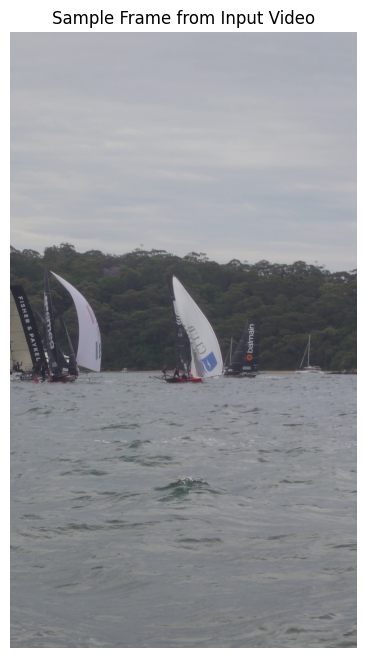

2025-11-15 14:55:01.285 | INFO     | __main__:<module>:15 - Running detection on sample frame...
2025-11-15 14:55:01.428 | INFO     | __main__:<module>:20 - Total objects detected: 4
2025-11-15 14:55:01.429 | INFO     | __main__:<module>:29 -   Boat detected: boat (confidence: 0.33)
2025-11-15 14:55:01.429 | INFO     | __main__:<module>:29 -   Boat detected: boat (confidence: 0.16)
2025-11-15 14:55:01.430 | INFO     | __main__:<module>:29 -   Boat detected: boat (confidence: 0.10)
2025-11-15 14:55:01.430 | INFO     | __main__:<module>:29 -   Boat detected: boat (confidence: 0.10)
2025-11-15 14:55:01.431 | INFO     | __main__:<module>:31 - Boat-specific detections: 4


In [5]:
# Read and display first frame
if os.path.exists(INPUT_VIDEO_PATH):
    cap = cv2.VideoCapture(INPUT_VIDEO_PATH)
    ret, sample_frame = cap.read()
    
    if ret:
        # Display the frame
        plt.figure(figsize=(12, 8))
        plt.imshow(cv2.cvtColor(sample_frame, cv2.COLOR_BGR2RGB))
        plt.title("Sample Frame from Input Video")
        plt.axis('off')
        plt.show()
        
        # Test detection on sample frame
        logger.info("Running detection on sample frame...")
        results = model(sample_frame, conf=CONFIDENCE_THRESHOLD, verbose=False)
        
        if results[0].boxes is not None:
            detections = len(results[0].boxes)
            logger.info(f"Total objects detected: {detections}")
            
            # Check for boat-specific detections
            boat_detections = 0
            for box in results[0].boxes:
                class_id = int(box.cls[0].cpu().numpy())
                class_name = model.names[class_id]
                if any(boat_class in class_name.lower() for boat_class in ['boat', 'ship']):
                    boat_detections += 1
                    logger.info(f"  Boat detected: {class_name} (confidence: {box.conf[0]:.2f})")
            
            logger.info(f"Boat-specific detections: {boat_detections}")
        else:
            logger.info("No objects detected in sample frame")
    
    cap.release()
else:
    logger.info("Please provide a valid video file path first")

## Boat Detection Function

Create a function to detect boats in a single frame and draw bounding boxes.

In [6]:
def detect_boats_in_frame(frame, model, confidence=0.5):
    """
    Detect boats in a single frame
    
    Args:
        frame: Input image frame
        model: YOLO model
        confidence: Detection confidence threshold
    
    Returns:
        annotated_frame: Frame with bounding boxes
        detections: List of detection data
    """
    # Run detection
    results = model(frame, conf=confidence, verbose=False)
    
    # Extract detections
    detections = []
    annotated_frame = frame.copy()
    
    if results[0].boxes is not None:
        for box in results[0].boxes:
            # Get box coordinates
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
            confidence_score = box.conf[0].cpu().numpy()
            class_id = int(box.cls[0].cpu().numpy())
            class_name = model.names[class_id]
            
            # Filter for boat/ship classes
            if any(boat_class in class_name.lower() for boat_class in ['boat', 'ship']):
                detections.append({
                    'bbox': [int(x1), int(y1), int(x2), int(y2)],
                    'confidence': float(confidence_score),
                    'class': class_name
                })
                
                # Draw bounding box (green)
                cv2.rectangle(annotated_frame, (int(x1), int(y1)), (int(x2), int(y2)), (0, 255, 0), 2)
                
                # Add label with background
                label = f"{class_name}: {confidence_score:.2f}"
                label_size = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)[0]
                
                # Draw label background
                cv2.rectangle(annotated_frame, (int(x1), int(y1)-30), 
                             (int(x1) + label_size[0], int(y1)), (0, 255, 0), -1)
                
                # Draw label text
                cv2.putText(annotated_frame, label, (int(x1), int(y1)-10), 
                           cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 2)
    
    return annotated_frame, detections

logger.info("Boat detection function defined successfully!")

2025-11-15 14:55:09.218 | INFO     | __main__:<module>:54 - Boat detection function defined successfully!


## Main Processing Function

Create the main function to process the entire video.

In [7]:
def process_video(input_path, output_path, model, confidence=0.5):
    """
    Process entire video for boat detection and tracking
    """
    # Open input video
    cap = cv2.VideoCapture(input_path)
    
    if not cap.isOpened():
        raise ValueError(f"Could not open video file: {input_path}")
    
    # Get video properties
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    # Create output directory if it doesn't exist
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    
    # Setup output video writer
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))
    
    # Processing statistics
    stats = {
        'total_frames': total_frames,
        'processed_frames': 0,
        'boats_detected': 0,
        'detection_summary': []
    }
    
    frame_number = 0
    
    logger.info(f"Processing {total_frames} frames...")
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
            
        # Detect boats in current frame
        annotated_frame, detections = detect_boats_in_frame(frame, model, confidence)
        
        # Update statistics
        stats['processed_frames'] += 1
        if detections:
            stats['boats_detected'] += len(detections)
            stats['detection_summary'].append({
                'frame': frame_number,
                'boats': len(detections),
                'detections': detections
            })
        
        # Write annotated frame to output
        out.write(annotated_frame)
        
        # Progress update every 30 frames
        if frame_number % 30 == 0:
            progress = (frame_number / total_frames) * 100
            logger.info(f"Progress: {progress:.1f}% (Frame {frame_number}/{total_frames})")
        
        frame_number += 1
    
    # Cleanup
    cap.release()
    out.release()
    
    logger.info("Video processing completed!")
    return stats

logger.info("Video processing function defined successfully!")

2025-11-15 14:55:10.954 | INFO     | __main__:<module>:71 - Video processing function defined successfully!


## Run the Pipeline

Execute the main processing pipeline on your video.

In [8]:
# Check if input video exists before processing
if not os.path.exists(INPUT_VIDEO_PATH):
    logger.info(f"ERROR: Video file not found at {INPUT_VIDEO_PATH}")
    logger.info("Please update INPUT_VIDEO_PATH in cell 2 to point to your video file")
    logger.info("\nExample formats:")
    logger.info('  INPUT_VIDEO_PATH = "C:/path/to/your/video.mp4"')
    logger.info('  INPUT_VIDEO_PATH = "input/sample_video.mov"')
else:
    # Process the video
    logger.info("Starting boat detection and tracking...")
    start_time = time.time()
    
    try:
        processing_stats = process_video(
            INPUT_VIDEO_PATH, 
            f"{OUTPUT_FOLDER_PATH}\\20251019 Broken Balmain_tracked.mp4", 
            model, 
            CONFIDENCE_THRESHOLD
        )
        
        end_time = time.time()
        processing_time = end_time - start_time
        
        logger.info(f"\n{'='*50}")
        logger.info(f"PROCESSING COMPLETED SUCCESSFULLY!")
        logger.info(f"{'='*50}")
        logger.info(f"Processing time: {processing_time:.2f} seconds")
        logger.info(f"Total frames processed: {processing_stats['processed_frames']}")
        logger.info(f"Total boat detections: {processing_stats['boats_detected']}")
        
        if processing_stats['processed_frames'] > 0:
            avg_detections = processing_stats['boats_detected'] / processing_stats['processed_frames']
            logger.info(f"Average detections per frame: {avg_detections:.2f}")
            
        logger.info(f"Output saved to: {OUTPUT_FOLDER_PATH}")
        
    except Exception as e:
        logger.info(f"ERROR during processing: {e}")
        logger.info("Please check your video file and try again")

2025-11-15 14:55:12.639 | INFO     | __main__:<module>:10 - Starting boat detection and tracking...
2025-11-15 14:55:12.772 | INFO     | __main__:process_video:34 - Processing 991 frames...
2025-11-15 14:55:12.935 | INFO     | __main__:process_video:60 - Progress: 0.0% (Frame 0/991)
2025-11-15 14:55:15.873 | INFO     | __main__:process_video:60 - Progress: 3.0% (Frame 30/991)
2025-11-15 14:55:18.759 | INFO     | __main__:process_video:60 - Progress: 6.1% (Frame 60/991)
2025-11-15 14:55:21.651 | INFO     | __main__:process_video:60 - Progress: 9.1% (Frame 90/991)
2025-11-15 14:55:24.538 | INFO     | __main__:process_video:60 - Progress: 12.1% (Frame 120/991)
2025-11-15 14:55:27.279 | INFO     | __main__:process_video:60 - Progress: 15.1% (Frame 150/991)
2025-11-15 14:55:30.090 | INFO     | __main__:process_video:60 - Progress: 18.2% (Frame 180/991)
2025-11-15 14:55:32.899 | INFO     | __main__:process_video:60 - Progress: 21.2% (Frame 210/991)
2025-11-15 14:55:35.660 | INFO     | __main

## 9. Display Results

Show sample detections and display the output video if possible.

In [ ]:
# Display sample results if processing was successful
if 'processing_stats' in locals() and processing_stats['detection_summary']:
    logger.info("Sample Detection Results:")
    logger.info("-" * 40)
    
    # Show first 5 detections
    for i, detection in enumerate(processing_stats['detection_summary'][:5]):
        logger.info(f"Frame {detection['frame']}: {detection['boats']} boat(s) detected")
        for boat in detection['detections']:
            bbox = boat['bbox']
            logger.info(f"  - {boat['class']} (confidence: {boat['confidence']:.2f})")
            logger.info(f"    Bounding box: [{bbox[0]}, {bbox[1]}, {bbox[2]}, {bbox[3]}]")
    
    if len(processing_stats['detection_summary']) > 5:
        logger.info(f"  ... and {len(processing_stats['detection_summary']) - 5} more detections")
    
    # Try to display output video if it's not too large
    if os.path.exists(OUTPUT_VIDEO_PATH):
        file_size_mb = os.path.getsize(OUTPUT_VIDEO_PATH) / (1024 * 1024)
        logger.info(f"\nOutput video size: {file_size_mb:.1f} MB")
        
        if file_size_mb < 50:  # Less than 50MB
            logger.info("Displaying output video:")
            display(Video(OUTPUT_VIDEO_PATH, width=800))
        else:
            logger.info("Video too large to display inline")
            logger.info(f"Please open the file directly: {OUTPUT_VIDEO_PATH}")
    
elif 'processing_stats' in locals():
    logger.info("No boats were detected in the video.")
    logger.info("You might want to:")
    logger.info("- Lower the confidence threshold")
    logger.info("- Try a different video with visible boats")
    logger.info("- Check if the video contains boat-like objects")
else:
    logger.info("Please run the processing pipeline first (cell 8)")

## 10. Detection Analysis and Visualization

Analyze detection patterns over time and create visualizations.

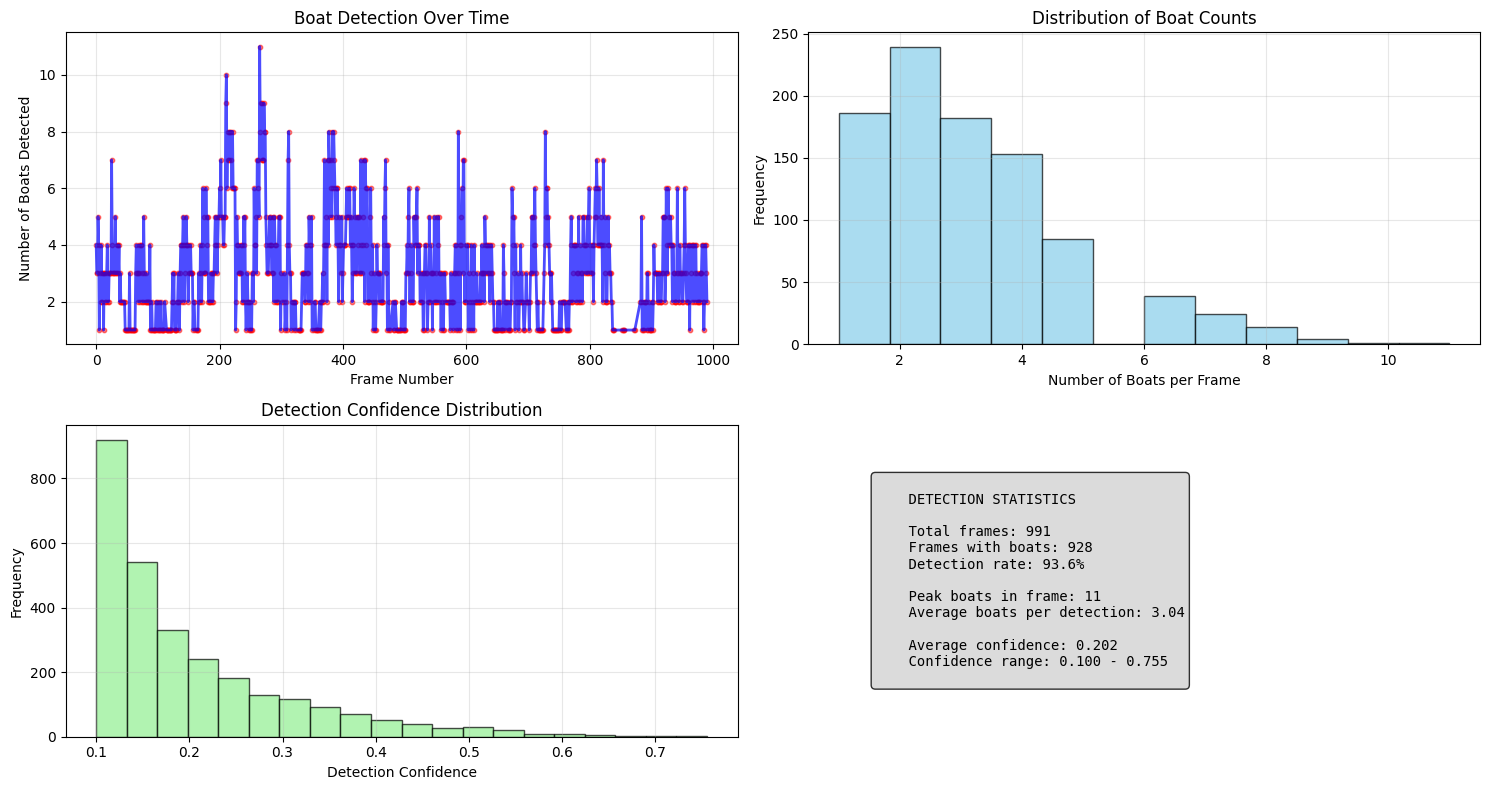

2025-11-15 14:58:27.597 | INFO     | __main__:<module>:79 - 
2025-11-15 14:58:27.598 | INFO     | __main__:<module>:80 - DETECTION ANALYSIS SUMMARY
2025-11-15 14:58:27.598 | INFO     | __main__:<module>:81 - ==================================================
2025-11-15 14:58:27.598 | INFO     | __main__:<module>:82 - Peak boats in single frame: 11
2025-11-15 14:58:27.599 | INFO     | __main__:<module>:83 - Frames with boats detected: 928
2025-11-15 14:58:27.599 | INFO     | __main__:<module>:84 - Detection rate: 93.6%
2025-11-15 14:58:27.599 | INFO     | __main__:<module>:85 - Average confidence: 0.202


In [9]:
# Analyze detection patterns if we have results
if 'processing_stats' in locals() and processing_stats['detection_summary']:
    # Extract data for plotting
    frame_numbers = [d['frame'] for d in processing_stats['detection_summary']]
    boat_counts = [d['boats'] for d in processing_stats['detection_summary']]
    
    # Plot detection over time
    plt.figure(figsize=(15, 8))
    
    # Subplot 1: Detections over time
    plt.subplot(2, 2, 1)
    plt.plot(frame_numbers, boat_counts, 'b-', alpha=0.7, linewidth=2)
    plt.scatter(frame_numbers, boat_counts, color='red', alpha=0.5, s=10)
    plt.xlabel('Frame Number')
    plt.ylabel('Number of Boats Detected')
    plt.title('Boat Detection Over Time')
    plt.grid(True, alpha=0.3)
    
    # Subplot 2: Detection histogram
    plt.subplot(2, 2, 2)
    plt.hist(boat_counts, bins=max(boat_counts)+1, alpha=0.7, color='skyblue', edgecolor='black')
    plt.xlabel('Number of Boats per Frame')
    plt.ylabel('Frequency')
    plt.title('Distribution of Boat Counts')
    plt.grid(True, alpha=0.3)
    
    # Subplot 3: Confidence distribution
    plt.subplot(2, 2, 3)
    all_confidences = []
    for detection in processing_stats['detection_summary']:
        for boat in detection['detections']:
            all_confidences.append(boat['confidence'])
    
    if all_confidences:
        plt.hist(all_confidences, bins=20, alpha=0.7, color='lightgreen', edgecolor='black')
        plt.xlabel('Detection Confidence')
        plt.ylabel('Frequency')
        plt.title('Detection Confidence Distribution')
        plt.grid(True, alpha=0.3)
    
    # Subplot 4: Summary statistics
    plt.subplot(2, 2, 4)
    plt.axis('off')
    
    # Calculate statistics
    total_detections = len(processing_stats['detection_summary'])
    peak_boats = max(boat_counts)
    avg_boats = sum(boat_counts) / len(boat_counts)
    detection_rate = (total_detections / processing_stats['processed_frames']) * 100
    
    if all_confidences:
        avg_confidence = sum(all_confidences) / len(all_confidences)
        min_confidence = min(all_confidences)
        max_confidence = max(all_confidences)
    else:
        avg_confidence = min_confidence = max_confidence = 0
    
    stats_text = f"""
    DETECTION STATISTICS
    
    Total frames: {processing_stats['processed_frames']}
    Frames with boats: {total_detections}
    Detection rate: {detection_rate:.1f}%
    
    Peak boats in frame: {peak_boats}
    Average boats per detection: {avg_boats:.2f}
    
    Average confidence: {avg_confidence:.3f}
    Confidence range: {min_confidence:.3f} - {max_confidence:.3f}
    """
    
    plt.text(0.1, 0.5, stats_text, fontsize=10, verticalalignment='center', 
             fontfamily='monospace', bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    # Summary statistics
    logger.info(f"\n{'='*50}")
    logger.info(f"DETECTION ANALYSIS SUMMARY")
    logger.info(f"{'='*50}")
    logger.info(f"Peak boats in single frame: {peak_boats}")
    logger.info(f"Frames with boats detected: {total_detections}")
    logger.info(f"Detection rate: {detection_rate:.1f}%")
    logger.info(f"Average confidence: {avg_confidence:.3f}")
    
elif 'processing_stats' in locals():
    logger.info("No detections to analyze. Try lowering the confidence threshold or using a different video.")
else:
    logger.info("Please run the processing pipeline first (cell 8)")

## Next Steps

Congratulations! You've successfully built a boat tracking pipeline. Here are some ideas for improvements:

### Immediate Enhancements:
1. **Adjust confidence threshold** - Try different values (0.3, 0.7) to see the effect
2. **Add tracking IDs** - Use YOLO's tracking feature to follow individual boats
3. **Filter by size** - Remove very small detections that might be false positives

### Advanced Features:
1. **Speed calculation** - Track boat movement between frames
2. **Boat counting** - Count unique boats entering/leaving the frame
3. **Export data** - Save detection coordinates to CSV for further analysis
4. **Real-time processing** - Process live video streams

### Try These Experiments:
```python
# Different confidence thresholds
CONFIDENCE_THRESHOLD = 0.3  # More detections, possibly more false positives
CONFIDENCE_THRESHOLD = 0.7  # Fewer but more confident detections

# Different YOLO models
MODEL_PATH = "yolov8s.pt"  # Slower but more accurate
MODEL_PATH = "yolov8m.pt"  # Even more accurate
```